In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from src.preprocessing import add_features, clean_data, load_data, split_data, build_preprocessor, RANDOM_STATE
from sklearn.pipeline import Pipeline

DATA_PATH = Path("../data/raw/Churn_Modelling.csv")

In [2]:
df = load_data(DATA_PATH)
df = clean_data(df)
df = add_features(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

print(X_train.shape, X_val.shape, X_test.shape)

(6999, 18) (1501, 18) (1500, 18)


In [3]:
preprocessor = build_preprocessor(X_train)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")),
    ]
)

baseline_model.fit(X_train, y_train)
y_val_pred = baseline_model.predict(X_val)

In [4]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1195
           1       0.40      0.66      0.50       306

    accuracy                           0.73      1501
   macro avg       0.65      0.70      0.66      1501
weighted avg       0.80      0.73      0.75      1501



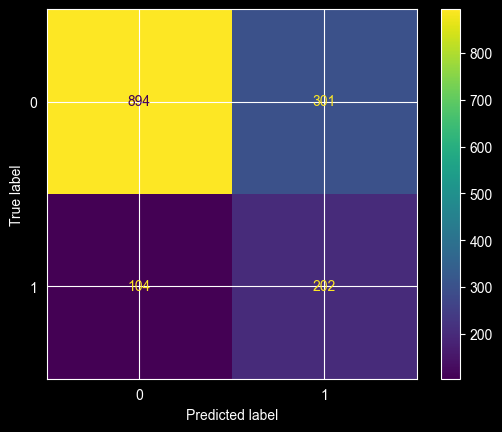

In [5]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)